Name: Kushagra Singh

Approach: 

1. Problem Understanding
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Defining Instructor Effectiveness
5. Feature Engineering, Aggregation and Instructor-Level Dataset Creation
6. Model Building, Evaluation and Interpretation
7. Business Insights
8. Answers to Mandatory Questions

1. Problem understanding: 

    I understand that the goal of this particular assignment is to estimate instructor effectiveness based on learner outcomes, engagement, and feedback metrics across multiple batches. Since instructors teach multiple batches, batch-level data must be aggregated to capture consistent teaching patterns rather than individual batch fluctuations

2. Data loading: 

In [3]:
import pandas as pd                    

dataset = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv") 

3. EDA: 

In [4]:
print(dataset.head()) 
print(dataset.info())

  batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0   B_1861         I_044      C_01         0.300000              14.225955   
1   B_0354         I_119      C_06         0.657220              22.871110   
2   B_1334         I_050      C_03         0.300000              16.087517   
3   B_0906         I_024      C_21         0.639507              24.260687   
4   B_1290         I_001      C_08         0.527302              31.081556   

   avg_quiz_score  dropout_rate  avg_watch_time  assignment_submission_rate  \
0       73.546528      0.647423        0.774572                    0.790918   
1       77.312331      0.425098        0.494936                    0.998566   
2       79.563687      0.700000        0.977901                    0.807298   
3       99.295316      0.334657        0.846515                    0.544555   
4       99.393425      0.521099        0.917450                    0.865885   

   forum_activity_rate  avg_feedback_score  feedback_res

In [5]:
print(dataset.describe())

       completion_rate  avg_score_improvement  avg_quiz_score  dropout_rate  \
count      2000.000000            2000.000000     2000.000000   2000.000000   
mean          0.602808              27.035844       77.956126      0.394883   
std           0.159667               5.716641       10.695618      0.162747   
min           0.300000               6.159240       40.386725      0.020000   
25%           0.489260              23.124673       70.897590      0.280035   
50%           0.603091              26.938629       78.020567      0.394820   
75%           0.712797              30.885600       85.444286      0.511432   
max           0.980000              40.000000      100.000000      0.700000   

       avg_watch_time  assignment_submission_rate  forum_activity_rate  \
count     2000.000000                 2000.000000          2000.000000   
mean         0.776515                    0.753188             0.250300   
std          0.145231                    0.148058             0.10

In [ ]:
print(dataset.isnull().sum()) 
#This shows that our dataset has no missing values

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64


Since each instructor teaches multiple batches, we will visualize it using plot.

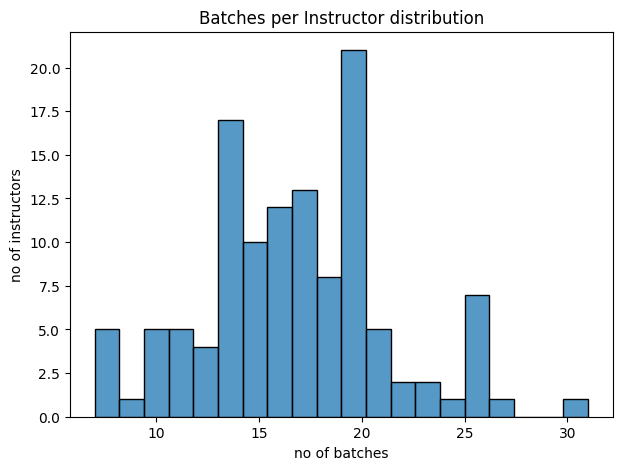

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

batch_count = dataset.groupby("instructor_id").size() 
plt.figure(figsize=(7,5)) 
sns.histplot(batch_count, bins=20) 
plt.title("Batches per Instructor distribution")
plt.xlabel("no of batches") 
plt.ylabel("no of instructors") 
plt.show() 

#Most instructors teach between 13 and 20 batches. This suggests we have sufficient data per instructor to estimate overall teaching effectiveness reliably.

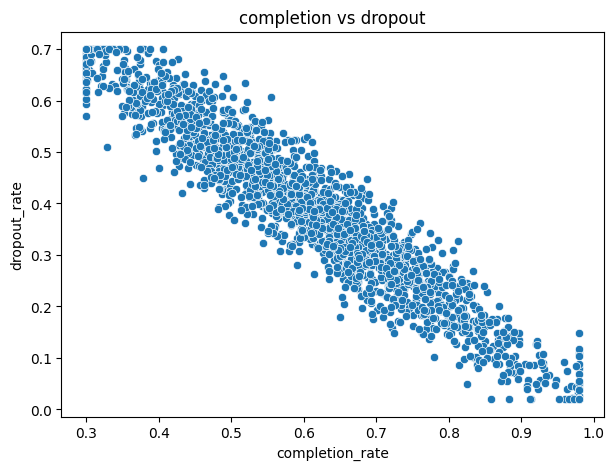

In [ ]:
plt.figure(figsize=(7,5)) 
sns.scatterplot(x=dataset["completion_rate"], y=dataset["dropout_rate"]) 
plt.title("completion vs dropout") 
plt.show()  

#Batches with high completion rate have low dropout rate and vice versa. Thus, they have a negative relationship

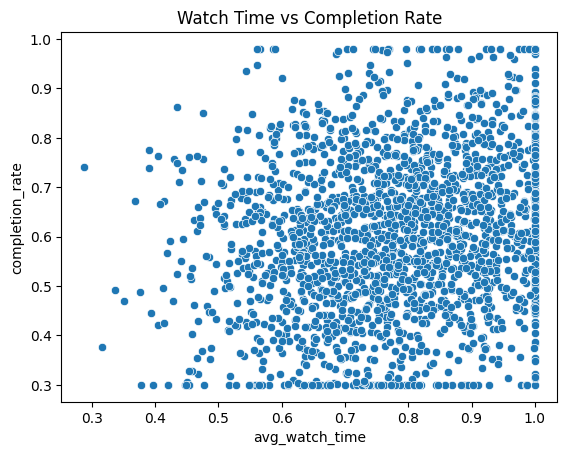

In [ ]:
sns.scatterplot(x=dataset["avg_watch_time"], y=dataset["completion_rate"])
plt.title("Watch Time vs Completion Rate")
plt.show() 

#This plot shows that higher the watchtime, higher the completion rate

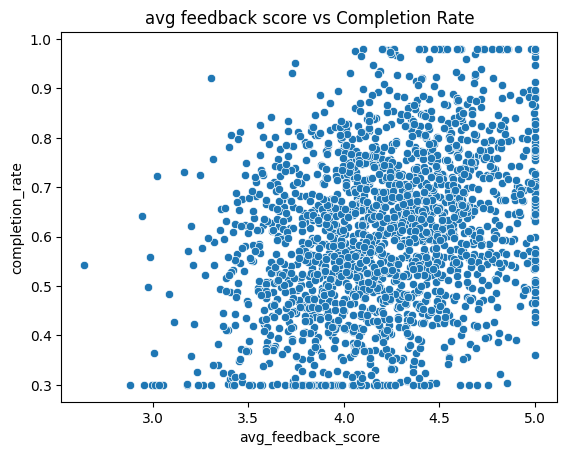

In [ ]:
sns.scatterplot(x=dataset["avg_feedback_score"], y=dataset["completion_rate"])
plt.title("avg feedback score vs Completion Rate")
plt.show() 

#this shows that courses with higher feedback score have better completion rate, indicating that perceived instructor quality may impact learner persistence.

To better understand the relationship between different columns, I will now use a correlation matrix. 
This will help me to identify strong relationships between engagement and learning outcomes along with variables that may influence instructor effectiveness. 

In [14]:
num_columns = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time",
    "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"] 

corr_matrix = dataset[num_columns].corr() 
print(corr_matrix) 

                            completion_rate  dropout_rate  \
completion_rate                    1.000000     -0.953493   
dropout_rate                      -0.953493      1.000000   
avg_score_improvement              0.404161     -0.381354   
avg_quiz_score                     0.333307     -0.315220   
avg_watch_time                     0.187633     -0.170536   
assignment_submission_rate         0.221877     -0.210486   
forum_activity_rate                0.205793     -0.200598   
avg_feedback_score                 0.315394     -0.300556   
feedback_response_rate             0.279549     -0.274475   

                            avg_score_improvement  avg_quiz_score  \
completion_rate                          0.404161        0.333307   
dropout_rate                            -0.381354       -0.315220   
avg_score_improvement                    1.000000        0.218788   
avg_quiz_score                           0.218788        1.000000   
avg_watch_time                           0.1

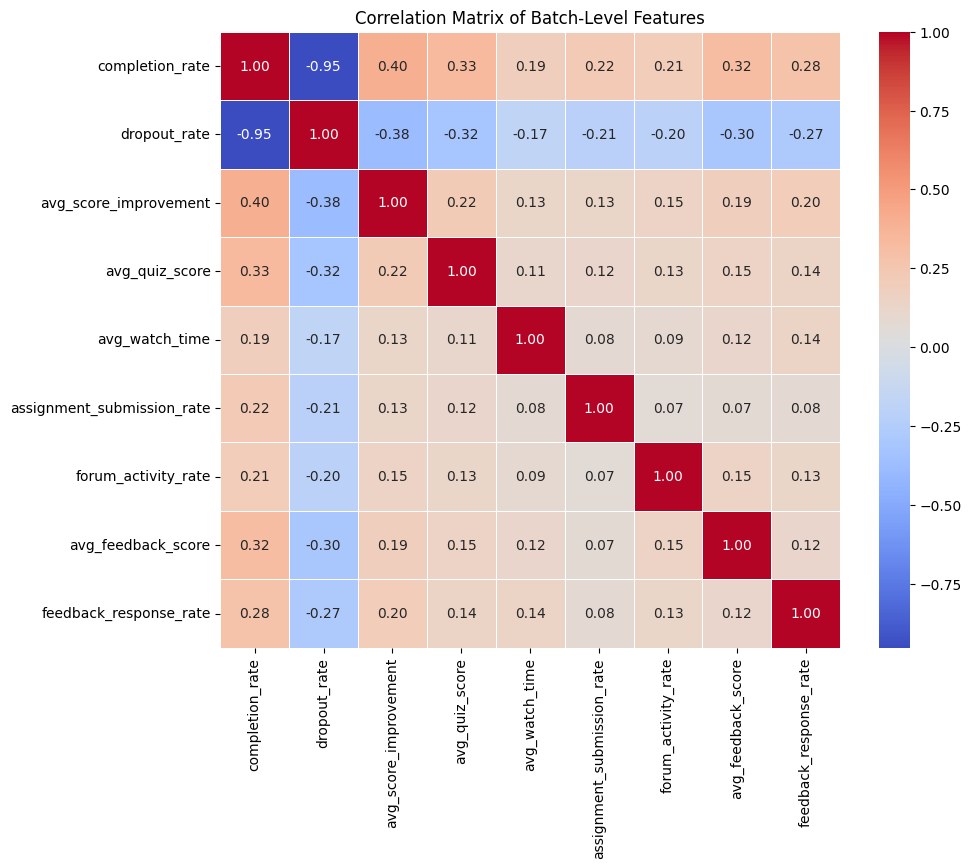

In [ ]:
#visualizing the correlation matrix for better understanding 
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Batch-Level Features")
plt.show()

Key Observations:

Several meaningful relationships emerge from the correlation analysis:

1. Completion rate and dropout rate show a strong negative correlation, which is expected since higher dropout typically reduces course completion.

2. Engagement metrics such as average watch time and assignment submission rate show positive correlations with completion rate. This suggests that higher learner engagement is associated with better learning outcomes.

3. Feedback scores show moderate positive correlation with engagement and completion metrics, indicating that students tend to rate courses higher when they are more engaged and complete the course successfully.

4. Forum activity appears to have a weaker correlation with other variables, suggesting it may capture a different type of engagement behavior.

5. Avg score improvement and Avg quiz score show moderately positive correlation with completion rate.

These insights support the inclusion of outcome, engagement, and feedback metrics in the instructor effectiveness score. We observe that learning outcome metrics such as quiz score and completion rate are moderately correlated with engagement variables. These insights support incorporating outcome, engagement, and feedback metrics when defining instructor effectiveness.

Based on the above correlation analysis, I will now design an instructor effectiveness score that incorporates three major dimensions of teaching impact: learning outcomes, student engagement, and learner feedback.

4. Defining instructor effectiveness: 

In [18]:
dataset["outcome_score"] = (0.4 * dataset["completion_rate"] + 0.3 * dataset["avg_score_improvement"] + 0.3 * dataset["avg_quiz_score"] - 0.3 * dataset["dropout_rate"])

dataset["engagement_score"] = (0.4 * dataset["avg_watch_time"] + 0.3 * dataset["assignment_submission_rate"] + 0.3 * dataset["forum_activity_rate"])

dataset["feedback_score"] = (0.7 * (dataset["avg_feedback_score"] / 5) + 0.3 * dataset["feedback_response_rate"])

dataset["effectiveness_score"] = (0.4 * dataset["outcome_score"] + 0.35 * dataset["engagement_score"] + 0.25 * dataset["feedback_score"])

In [ ]:
dataset["effectiveness_tier"] = pd.qcut(dataset["effectiveness_score"], q=3, labels=["Low","Medium","High"]) 
dataset["effectiveness_tier"].value_counts() 
#This shows that we have no class imbalance which will lead to better training

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

5. Feature Engineering, Aggregation and Instructor-Level Dataset Creation: 

In [ ]:
num_columns = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time",
    "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate", "effectiveness_score"] 

# Aggregating batch-level features to instructor-level
instructor_data = dataset.groupby("instructor_id")[num_columns].mean() 
instructor_data["num_batches"] = dataset.groupby("instructor_id").size()
instructor_data = instructor_data.reset_index() 

In [23]:
instructor_data["effectiveness_tier"] = pd.qcut(instructor_data["effectiveness_score"], 3, labels=["Low","Medium","High"]) 
print(instructor_data["effectiveness_tier"]) 
#Instructor_data now has 120 rows, 1 row per instructor

0      Medium
1        High
2        High
3         Low
4        High
        ...  
115    Medium
116      High
117      High
118    Medium
119    Medium
Name: effectiveness_tier, Length: 120, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']


Preparing the dataset for training

In [42]:
X = instructor_data.drop(["instructor_id","effectiveness_tier", "effectiveness_score"], axis=1)
Y = instructor_data["effectiveness_tier"]

6. Model Building, Evaluation and Interpretation: 

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42) 

To improve model performance and reduce overfitting, we perform hyperparameter tuning using cross-validation. 
Cross-validation divides the training dataset into multiple folds. The model is trained on a subset of the data and validated on the remaining fold. This process repeats multiple times and the average performance is used to select the best hyperparameters.

This approach helps reduce overfitting and provides a more reliable estimate of model performance.

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV 

param_grid = {"n_estimators": [50, 75, 100],"max_depth": [3, 4, 5], "min_samples_split": [3, 4, 5]} 

model = RandomForestClassifier(random_state=42) 
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1) 
grid_search.fit(X_train, Y_train)  

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 4, 'min_samples_split': 3, 'n_estimators': 50}


In [ ]:
print("Best CV Score:", grid_search.best_score_) 
#This is the best cross validation accuracy of the model: 88.52%

Best CV Score: 0.8852631578947368


In [ ]:
final_model = grid_search.best_estimator_      #choosing to train the model with best hyperparameter values

preds = final_model.predict(X_test)            #predicting using the best model on the unseen test set

In [50]:
from sklearn.metrics import classification_report 

print(classification_report(Y_test, preds)) 

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         7
         Low       0.67      0.80      0.73         5
      Medium       0.91      0.83      0.87        12

    accuracy                           0.88        24
   macro avg       0.86      0.88      0.87        24
weighted avg       0.89      0.88      0.88        24



Model Performance Analysis: 

The model performs excellent in identifying highly effective instructors and achieves perfect precision and recall for the "High" tier in the test set. This means that strong engagement and outcome metrics provide clear signals of high instructor effectiveness.

Performance for the "Medium" tier is also strong, with balanced precision and recall. However, the model struggles with the "Low" tier, where precision is low. This indicates that distinguishing between low-performing instructors from moderately performing ones may be more difficult because their engagement and outcome metrics overlap.

7. Business Insights: 

    The model shows stronger performance for the "High" effectiveness category compared to the "Low" category.

    This pattern is common in educational data, where highly effective instructors tend to consistently produce strong engagement and completion metrics. In contrast, low-performing instructors may still occasionally produce acceptable batch outcomes due to course difficulty variations or student cohort differences.

    As a result, separating low and medium effectiveness instructors is a more challenging classification problem.

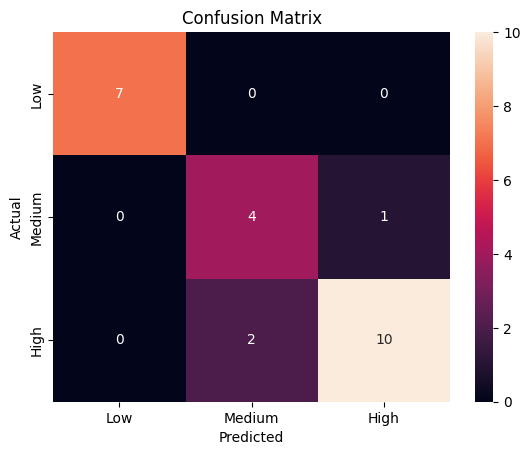

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, preds)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show() 
#The confusion matrix shows that most classification errors occur between the "Low" and "Medium" effectiveness tiers, supporting the earlier observation that these groups have overlapping characteristics.

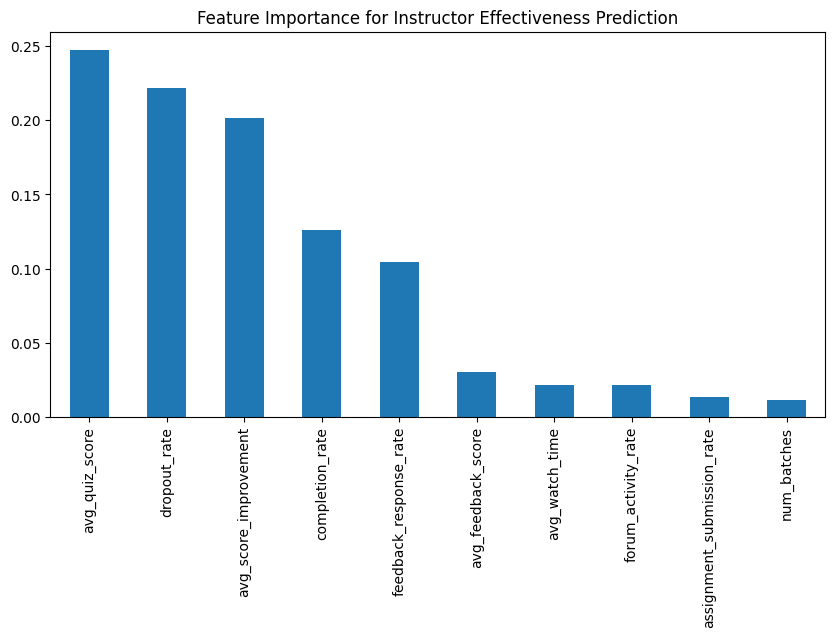

In [52]:
importance = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind="bar", figsize=(10,5))

plt.title("Feature Importance for Instructor Effectiveness Prediction")
plt.show()

Feature Importance Analysis and other business insights:

The Random Forest model highlights several key features that strongly influence instructor effectiveness predictions.

The most important feature is average quiz score, suggesting that instructors whose students perform better in assessments are more likely to be categorized as highly effective. This indicates that measurable learning outcomes play a major role in evaluating teaching performance.

The dropout rate is the second most important feature. A high dropout rate often indicates that learners disengage from the course, which may reflect issues with course delivery, clarity, or engagement.

Average score improvement is also highly influential. This metric captures the learning gain experienced by students during the course, which is a strong indicator of instructional impact.

Completion rate also contributes meaningfully to the model. Courses with higher completion rates generally indicate that learners remain engaged and are able to successfully progress through the material.

Interestingly, engagement metrics such as watch time and forum activity have lower importance in the model. This suggests that while engagement behaviors are useful indicators, they may be less predictive of instructor effectiveness compared to direct learning outcomes. 

It is important to note that feature importance in tree-based models reflects predictive power rather than causal relationships. 
For example, high quiz scores may indicate effective teaching, but they may also reflect easier course material or a more prepared student cohort.



Another interesting observation is that the number of batches taught by an instructor has very low importance. This suggests that instructor experience alone does not necessarily translate into higher effectiveness. Instead, the quality of learning outcomes and student retention appear to matter more than the quantity of courses taught.

More insights: 

Although the model achieves strong performance, a small dataset of 120 instructors means results may vary with different data splits. Cross-validation was therefore used during hyperparameter tuning to ensure that the model generalizes across different subsets of the data.
Since the model operates on aggregated instructor-level features rather than individual batch data, it captures overall teaching patterns rather than single-course performance fluctuations. 

All these findings suggest that edtech platforms that are aiming to improve teaching effectiveness should prioritize metrics related to learning outcomes and student retention. The platform could use this model to identify highly effective instructors and surface their courses more prominently or use them as mentors for other instructors.

For example, identifying instructors whose students consistently achieve high quiz scores and low dropout rates could help the platform highlight high-quality courses or develop mentorship programs where top-performing instructors share best practices with others.

Potential Platform Applications: 

The proposed model could help EdTech platforms identify instructors who consistently drive strong learner outcomes. These insights could support instructor training programs, highlight best teaching practices, and help surface high-performing instructors to learners.

Final Conclusion:

This analysis demonstrates that instructor effectiveness can be reasonably predicted using learner outcome, engagement, and feedback metrics. The model achieved strong performance with approximately 88% accuracy. Feature importance analysis suggests that learning outcomes, particularly quiz performance and dropout rates, are the strongest predictors of instructor effectiveness. These insights could help EdTech platforms identify high-performing instructors and design targeted support strategies for improving course quality.

8. Answers to Mandatory Questions: 

Q1. Which features most influenced instructor effectiveness, and why?

A1. Based on the feature importance analysis from the Random Forest model, the most influential variables were:

Average quiz score,  Dropout rate,  Average score improvement,  Completion rate.  

These features directly capture the learning outcomes and retention of students within a course.

Average quiz score and score improvement represent measurable academic performance and learning gain. Instructors whose students perform well in assessments are more likely to deliver clear explanations, effective teaching strategies, and well-structured content.

Dropout rate is also a strong indicator of teaching effectiveness. High dropout rates may suggest that students struggle to follow the material, lose motivation, or disengage from the course.

Completion rate further reinforces this relationship, as courses with higher completion typically reflect better student engagement and instructional clarity.

Overall, the model suggests that learning outcomes and student retention metrics are the strongest indicators of instructor effectiveness, while engagement behaviors such as forum activity and watch time play a smaller predictive role.

Q2. Which variables could be misleading or confounded?

A2. Some variables in the dataset may be influenced by factors outside an instructor's control, which can introduce confounding effects.

For example, average quiz score may depend heavily on course difficulty. Instructors teaching easier courses may appear more effective simply because assessments are less challenging.

Similarly, dropout rate may be influenced by external factors such as student motivation, prior knowledge, or time availability rather than purely instructional quality.

Feedback scores may also be biased, as students sometimes rate instructors based on course difficulty or grading leniency rather than teaching effectiveness.

Additionally, engagement metrics such as watch time or forum activity may vary depending on course format or topic complexity rather than the instructor's teaching ability.

Because of these factors, the model should be interpreted carefully, and these variables should not be assumed to represent purely causal relationships.

Q3. How could this model fail in real-world usage?

A3. Although the model performs well on the available dataset, several limitations could affect its reliability in real-world deployment.

First, the dataset does not account for differences in course difficulty. Instructors teaching more advanced or challenging subjects may naturally have lower completion rates or quiz scores, which could lead the model to incorrectly classify them as less effective.

Second, student cohorts may vary across batches. Some groups of learners may be more motivated, better prepared, or more experienced with online learning platforms, which could influence engagement and performance metrics.

Third, the model relies on aggregated instructor-level features. While this helps capture general teaching patterns, it may overlook variation across individual batches or changes in instructor performance over time.

Lastly, the dataset size is relatively small (120 instructors), which may limit the model’s ability to generalize to new instructors or different course environments.

For these reasons, the model should be considered a decision-support tool rather than a definitive measure of instructor performance.

Q4. What additional data would you improve in this analysis?

A4. Several additional types of data could improve the robustness and fairness of the model.

Course difficulty indicators would be valuable, such as course level (beginner, intermediate, advanced) or historical performance benchmarks. These would help control for differences between easier and more challenging courses.

Student background information could also improve the analysis. For example, prior knowledge, educational background, or previous performance on the platform could help distinguish instructor impact from student characteristics.

Temporal data would also be useful, allowing the analysis to track how instructor performance evolves over time. This could identify instructors who improve through experience or training.

Finally, qualitative feedback such as student comments or teaching evaluations could provide richer insights into instructor effectiveness that are not captured by numerical engagement metrics.

Q5. Should this model be used for instructor performance evaluation?

A5. This model should not be used as the sole basis for evaluating instructor performance.

While the model provides several useful insights into patterns associated with effective teaching, it relies on metrics that may be influenced by factors outside the instructor's control, such as course difficulty, student background, or cohort motivation.

Using the model as a strict evaluation tool could unfairly penalize instructors teaching more difficult subjects or working with less prepared students.

Instead, the model should be used as a "decision-support tool" to identify trends and highlight potential areas for improvement. 
For example, the platform could use the model to identify instructors whose courses consistently show low engagement or high dropout rates and offer targeted support or training.

Thus, the model can contribute to improving educational quality without being used as a rigid or punitive evaluation mechanism.